# Exercise 14: Mediation

This homework assignment is designed to give you practice with mediation. You won't need to load in any data for this homework -- we'll simulate data instead.

---
## 1. Simulating data (3 points)


In this homework, we're going to simulate the relationship between age, word reading experience, and reading comprehension skill. Older children tend to be better at reading comprehension tasks, but this isn't just an inherent part of getting older. It's a combination of gaining more experience with reading, oral language skills, and executive functions development. In this homework, though, we're going to simplify this relationship down to a direct effect of age on reading comprehension (since improvements in oral language skills and executive functions are more guaranteed as children age than reading practice is), and a mediation of word reading experience.

In graphical form: 
![picture](https://drive.google.com/uc?id=1wdm9xuiJhBJor99-9GnicO2_rzkGWtfN)

Writing the relationship out formally: 

$$x = \beta_{xa} a + \beta_{x0} + \epsilon_{x}$$

$$c = \beta_{ca} a + \beta_{cx} x + \beta_{c0} + \epsilon_c$$



$c$ is reading comprehension, $x$ is word reading experience, and $a$ is age. $\beta_{c0}$ and $\beta_{x0}$ are intercept terms for their respective formulas, and $\epsilon_{c}$ and $\epsilon_{x}$ are gaussian noise terms. We'll start by writing a function, `simulate_data`, that can simulate this relationship. The input values are set and the function structure is provided below. Complete the function such that it takes in those input variables and generates $age$, $x$, and $c$ values. Use `runif()` to generate ages. Use `rnorm()` to generate the noise terms. 

In [1]:
sample_size = 100 # How many children in data set? 
age_lo = 80     # minimum age, in months
age_hi = 200    # maximum age, in months
beta_xa = 0.5   # amount by which experience changes for increase of one month in age
beta_x0 = -5    # amount of experience when age = 0 (not interpretable, since minimum age for this data is 80 months)
sd_x = 50       # standard dev of gaussian noise term, epsilon_x
beta_ca = 0.8   # amount that comprehension score improves for every increase of one unit in age
beta_cx = 3     # amount that comprehension score improves for every increase of one unit in reading experience
beta_c0 = 10    # comprehension score when reading experience is 0. 
sd_c = 85      # standard dev of gaussian noise term, epsilon_c

simulate_data <- function(sample_size, age_lo, age_hi, beta_xa, 
                          beta_x0, sd_x, beta_ca, beta_cx, beta_c0, sd_c) {
      # WRITE YOUR CODE HERE
      #HY: simulated data contains 3 values, age, implement the two equations - x, and c.
      #HY: runif(sample size, age_lo, age_hi)
      age = runif(sample_size, age_lo, age_hi)
      x = beta_xa*age + beta_x0 + rnorm(sample_size, 0, sd_x)
      c = beta_ca*age + beta_cx*x + beta_c0 + rnorm(sample_size, 0, sd_c)
      return(data.frame(age=age,x=x,c=c))
}     

dat <- simulate_data(sample_size, age_lo, age_hi, beta_xa, beta_x0, sd_x, beta_ca, beta_cx, beta_c0, sd_c)
str(dat)

'data.frame':	100 obs. of  3 variables:
 $ age: num  117 135 127 157 110 ...
 $ x  : num  17.97 172.78 17.16 149.32 8.37 ...
 $ c  : num  224.2 619.1 -28.5 530.8 132.9 ...


---
## 2. Visualizing Data (2 point)

Load the `tidyverse` library.

In [2]:
# WRITE YOUR CODE HERE
library(tidyverse)

-- Attaching core tidyverse packages ------------------------ tidyverse 2.0.0 --
v dplyr     1.1.4     v readr     2.1.5
v forcats   1.0.0     v stringr   1.5.1
v ggplot2   3.5.1     v tibble    3.2.1
v lubridate 1.9.4     v tidyr     1.3.1
v purrr     1.0.2     
-- Conflicts ------------------------------------------ tidyverse_conflicts() --
x dplyr::filter() masks stats::filter()
x dplyr::lag()    masks stats::lag()
i Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


a) Plot the relationship between age and reading comprehension. 

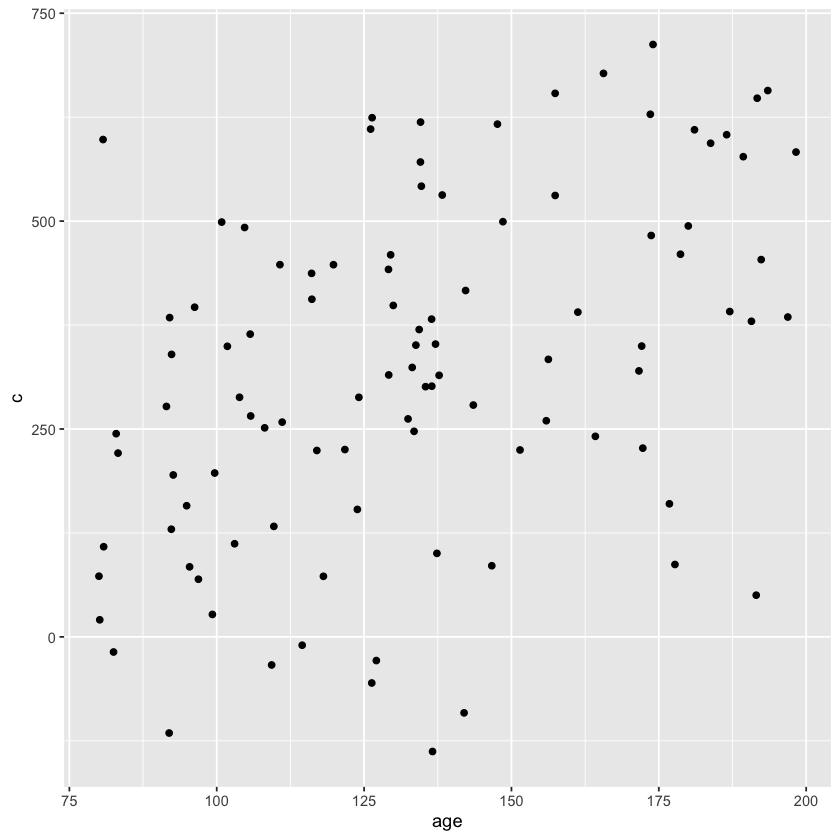

In [3]:
# WRITE YOUR CODE HERE
ggplot(dat, aes(x = age, y = c)) +
  geom_point()

b) Plot the relationship between reading experience, age, and reading comprehension.

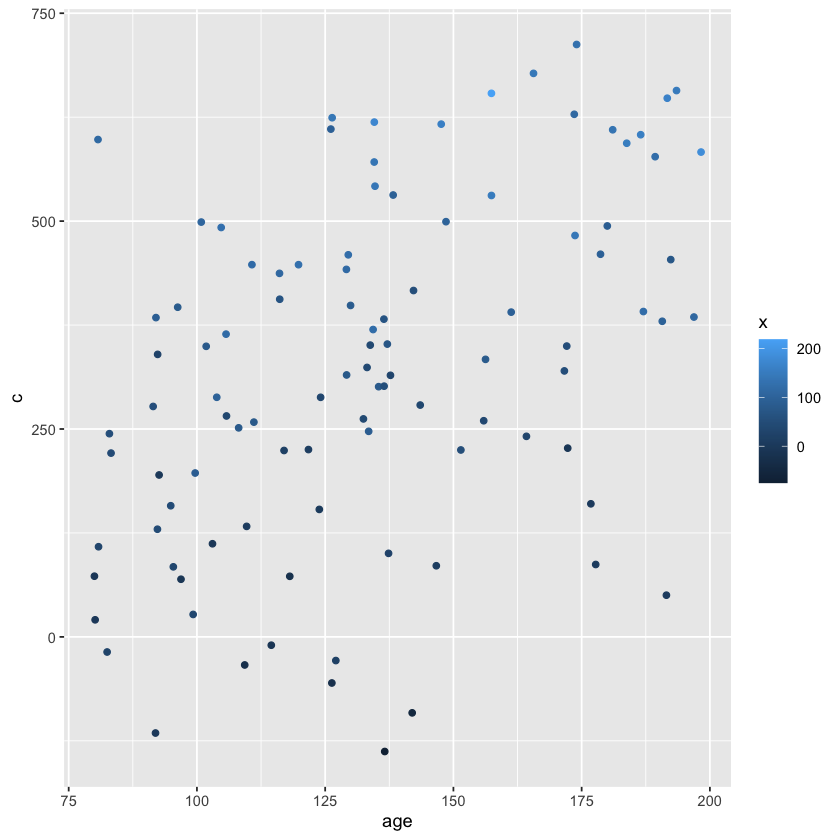

In [4]:
# WRITE YOUR CODE HERE
ggplot(dat, aes(x = age, y = c, color = x)) +
  geom_point()


---
## 3. Mediation Analysis (4 points)

Load the `mediation` library.

In [5]:
# WRITE YOUR CODE HERE
#install.packages('mediation')
library(mediation)

Loading required package: MASS


Attaching package: 'MASS'


The following object is masked from 'package:dplyr':

    select


Loading required package: Matrix


Attaching package: 'Matrix'


The following objects are masked from 'package:tidyr':

    expand, pack, unpack


Loading required package: mvtnorm

Loading required package: sandwich

mediation: Causal Mediation Analysis
Version: 4.5.0




Use the `mediate` function to determine whether `x` mediates the relationship between `age` and `c`. Use `summary()` to print the model results. *Hint: see the mediation and moderation tutorial.*

In [10]:
# WRITE YOUR CODE HERE
mod_1 <- lm(x ~ age, data = dat)
summary(mod_1)

mod_2 <- lm(c ~ age + x, data = dat)
summary(mod_2)



Call:
lm(formula = x ~ age, data = dat)

Residuals:
    Min      1Q  Median      3Q     Max 
-145.97  -40.44    2.21   42.69  135.02 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) -16.2212    22.3446  -0.726 0.469594    
age           0.6363     0.1617   3.936 0.000155 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 53.84 on 98 degrees of freedom
Multiple R-squared:  0.1365,	Adjusted R-squared:  0.1277 
F-statistic: 15.49 on 1 and 98 DF,  p-value: 0.0001549



Call:
lm(formula = c ~ age + x, data = dat)

Residuals:
    Min      1Q  Median      3Q     Max 
-187.86  -63.45   12.50   55.00  218.19 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)   5.5401    36.9326   0.150  0.88107    
age           0.7894     0.2868   2.753  0.00706 ** 
x             3.0497     0.1665  18.315  < 2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 88.75 on 97 degrees of freedom
Multiple R-squared:  0.8195,	Adjusted R-squared:  0.8158 
F-statistic: 220.2 on 2 and 97 DF,  p-value: < 2.2e-16


In [12]:
med_mod <- mediate(mod_1, mod_2, treat = "age", mediator = "x")
summary(med_mod)


Causal Mediation Analysis 

Quasi-Bayesian Confidence Intervals

               Estimate 95% CI Lower 95% CI Upper p-value    
ACME              1.921        0.967         2.91  <2e-16 ***
ADE               0.782        0.218         1.32   0.004 ** 
Total Effect      2.703        1.686         3.77  <2e-16 ***
Prop. Mediated    0.709        0.492         0.90  <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Sample Size Used: 100 


Simulations: 1000 


---
## 5. Reflection (1 point)
How do you interpret these results? Why do you think the analysis yielded this result?

> The results suggest that reading experience is a partial mediator between age and reading comprehension, since age and reading comprehension are still significantly related, while holding reading exprience constant. This because there might be other stronger mediator variables that account for the relationship between age and reading comprehension, such as family SES or number of languages spoken at home.

**DUE:** 5pm EST, April 1, 2024

**IMPORTANT** Did you collaborate with anyone on this assignment? If so, list their names here. 
> Emiliano.